# 04b — Calibrated dust attenuation (DustE replacement)

Successor to the exploration in `04a_dust_attenuation_simple.ipynb`: the same
two-component physics (Noll+09 modified Calzetti + Charlot & Fall birth
cloud), but with **parameters calibrated against real survey color
distributions (SDSS + DEEP2)** instead of hand-picked defaults.

The calibration was performed in
`/lcrc/project/cosmo_ai/nramachandra/Projects/SPHEREx/MAH/SEDPhot_v2/`
(`calibration/calibrate_dust.py`: z-binned Wasserstein distance between
synthetic and observed u−g, g−i, r−i, i−z distributions with the survey's
mag_i selection, on FSPS SEDs built from real SMDPL UniverseMachine SFHs).
This notebook is self-contained — the curve functions below are verified
against `sedpy` in-notebook, and the calibrated parameters are inlined (with
optional JSON reload).

## Why replace DustE — pitfalls found in production (July 2026)

DustE silently produces catastrophic attenuation (τ up to ~10³–10⁴,
A_i ≈ 12–20 mag, g−i ≈ 25) when its input conventions are violated:

1. **`sfr` must be log10(SFR)**, valid range **[−2.06, 2.11]**
   (`duste/DustAttnCalc.py` prop_dict). Passing linear SFR (e.g. 50 M⊙/yr)
   is 10–100× outside the model domain. *(This broke the SPHEREx/MAH
   training data; `watercolor.dust_attenuation.spectrum_dusted` has `sfr`
   commented out, so watercolor was safe.)*
2. **`wv_arr` must be REST-frame Angstroms.** Passing observed-frame
   wavelengths shifts the curve by (1+z). *(Moot for HACC z≈0 snapshots,
   fatal for lightcones.)*
3. Valid property ranges: logM ∈ [8.74, 11.30], logZ ∈ [−1.70, 0.18],
   **z ∈ [0.51, 2.83]** — HACC z≈0.001 galaxies are extrapolations.

The model below has none of these failure modes: inputs are explicit,
ranges are clipped, and the attenuation is a transparent analytic function.


In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

## The attenuation curves

Exact mirrors of `sedpy.attenuation.calzetti` / `noll` (which is what DustE
uses internally), so the physics is unchanged — only the *parameter
assignment* differs. Canonical maintained copy:
`SPHEREx/MAH/SEDPhot_v2/dust_model.py`.

In [2]:
R_V_CALZETTI = 4.05


def calzetti_k_over_kv(wave_aa):
    """Calzetti (2000) attenuation curve normalized to 1 at 5500 A.

    Exact mirror of sedpy.attenuation.calzetti(wave, tau_v=1, R_v=4.05):
    published polynomials on 1200-6300 A (UV) and 6300-22000 A (optical/NIR),
    linear extrapolation outside, clipped at zero.
    wave_aa: REST-FRAME Angstrom.
    """
    wave = np.asarray(wave_aa, dtype=float)
    r_v = R_V_CALZETTI

    def k_opt(x):   # x = 1e4 / lambda[A] = 1 / lambda[um]
        return 2.659 * (-1.857 + 1.040 * x)

    def k_uv(x):
        return 2.659 * (-2.156 + 1.509 * x - 0.198 * x**2 + 0.011 * x**3)

    uv_anchor = np.array([1200.0, 1300.0])
    kuv_anchor = k_uv(1e4 / uv_anchor) + r_v
    uv_slope = np.diff(kuv_anchor)[0] / np.diff(uv_anchor)[0]
    ir_anchor = np.array([21900.0, 22000.0])
    kir_anchor = k_opt(1e4 / ir_anchor) + r_v
    ir_slope = np.diff(kir_anchor)[0] / np.diff(ir_anchor)[0]
    k_v = k_uv(1e4 / 5500.0) + r_v

    x = 1e4 / wave
    ktot = np.where(wave < 1200.0,
                    kuv_anchor[0] + (wave - uv_anchor[0]) * uv_slope, 0.0)
    ktot = np.where((wave >= 1200.0) & (wave < 6300.0), k_uv(x) + r_v, ktot)
    ktot = np.where((wave >= 6300.0) & (wave <= 22000.0), k_opt(x) + r_v, ktot)
    ktot = np.where(wave > 22000.0,
                    kir_anchor[1] + (wave - ir_anchor[1]) * ir_slope, ktot)
    return np.clip(ktot, 0.0, None) / k_v


def drude_bump(wave_aa, x0=4.59, gamma=0.90):
    """2175 A bump (Drude in inverse-micron space), peak-normalized to 1 --
    identical to sedpy.attenuation.drude."""
    x = 1e4 / np.asarray(wave_aa, dtype=float)
    return (x * gamma)**2 / ((x**2 - x0**2)**2 + (x * gamma)**2)


def tau_diffuse(wave_aa, tau_v, n=0.0, apply_bump=True):
    """Diffuse-ISM optical depth: Noll+09 modified Calzetti.
    == sedpy.attenuation.noll(wave, tau_v, delta=n, c_r=0, Ebump=0.85-1.9n),
    which is DustE's get_dust_attn_curve_d2.  n=0, apply_bump=False -> pure
    Calzetti with tau(5500)=tau_v."""
    wave_aa = np.asarray(wave_aa, dtype=float)
    k = calzetti_k_over_kv(wave_aa)
    if apply_bump:
        ebump = 0.85 - 1.9 * n
        k = k + (ebump / R_V_CALZETTI) * drude_bump(wave_aa)
    return np.clip(tau_v * k * (wave_aa / 5500.0)**n, 0.0, None)


def tau_birthcloud(wave_aa, tau1):
    """Charlot & Fall (2000) birth-cloud screen, slope -1, tau1 at 5500 A
    (DustE's dust1 component)."""
    return tau1 * (np.asarray(wave_aa, dtype=float) / 5500.0)**(-1.0)

In [3]:
# Verify against sedpy (the reference implementation DustE uses)
from sedpy.attenuation import calzetti, noll

wave_test = np.linspace(300.0, 40000.0, 4000)
err_calz = np.max(np.abs(calzetti_k_over_kv(wave_test)
                         - calzetti(wave_test, tau_v=1.0, R_v=4.05)))
errs_noll = []
for tv in (0.1, 0.5, 1.5):
    for n in (-0.5, -0.1, 0.0, 0.3):
        ref = np.clip(noll(wave_test, tau_v=tv, delta=n, c_r=0.0,
                           Ebump=0.85 - 1.9 * n), 0.0, None)
        errs_noll.append(np.max(np.abs(tau_diffuse(wave_test, tv, n) - ref)))

print(f"max |ours - sedpy.calzetti| = {err_calz:.2e}")
print(f"max |ours - sedpy.noll|     = {max(errs_noll):.2e}")
assert err_calz < 1e-10 and max(errs_noll) < 1e-10
print("curves are identical to the sedpy/DustE forms")

max |ours - sedpy.calzetti| = 0.00e+00
max |ours - sedpy.noll|     = 3.55e-15
curves are identical to the sedpy/DustE forms


## Calibrated population model

Each galaxy draws its own τ_V from galaxy properties (never one value for
the whole population):

$$\tau_V = a\,10^{b(\log M_*-10)}\,10^{c\,\log Z}\,(1+z)^d\,
e^{\sigma\mathcal{N}(0,1)}, \qquad \tau_V \in [\tau_{min}, \tau_{max}]$$

Parameters below were fit to **SDSS + DEEP2** color distributions
(July 2026). An unconstrained fit drifts to a degenerate corner
(n→−1, σ→0); bounds were kept to observational ranges (σ ≥ 0.15,
n ∈ [−0.6, 0.4]) — see `SEDPhot_v2/calibration/calibrate_dust.py`.

In [4]:
# Calibrated to SDSS + DEEP2 (SEDPhot_v2, July 2026).  If the JSON produced
# by the calibration pipeline is reachable, prefer it (stays in sync with
# recalibrations); otherwise use the inlined snapshot.
CALIBRATED_PARAMS = dict(
    a=0.3833, b=0.1847, c=0.30, d=0.30,
    sigma=0.3577, n=-0.1093, mu=0.00134,
    tau_min=0.005, tau_max=4.0, apply_bump=True,
)

_CALIB_JSON = ('/lcrc/project/cosmo_ai/nramachandra/Projects/SPHEREx/MAH/'
               'SEDPhot_v2/outputs/dust_model_calibrated.json')
if os.path.exists(_CALIB_JSON):
    with open(_CALIB_JSON) as f:
        _loaded = json.load(f)
    _loaded.pop('meta', None)
    CALIBRATED_PARAMS.update(_loaded)
    print(f'loaded calibrated parameters from {_CALIB_JSON}')
else:
    print('calibration JSON not reachable; using inlined snapshot')
print({k: (round(v, 4) if isinstance(v, float) else v)
       for k, v in CALIBRATED_PARAMS.items()})

loaded calibrated parameters from /lcrc/project/cosmo_ai/nramachandra/Projects/SPHEREx/MAH/SEDPhot_v2/outputs/dust_model_calibrated.json
{'a': 0.3833, 'b': 0.1847, 'c': 0.3, 'd': 0.3, 'sigma': 0.3577, 'n': -0.1093, 'mu': 0.0013, 'tau_min': 0.005, 'tau_max': 4.0, 'apply_bump': True}


In [5]:
def tau_v_mean(logmass, logz=0.0, redshift=0.0, params=CALIBRATED_PARAMS):
    """Mean diffuse V-band optical depth.
    logmass: log10(M*/Msun); logz: log10(Z/Zsun); redshift: z."""
    p = params
    tau = (p['a'] * 10.0**(p['b'] * (np.asarray(logmass, dtype=float) - 10.0))
           * 10.0**(p['c'] * np.clip(np.asarray(logz, dtype=float), -2.0, 0.5))
           * (1.0 + np.clip(np.asarray(redshift, dtype=float), 0.0, 6.0))**p['d'])
    return np.clip(tau, p['tau_min'], p['tau_max'])


def draw_tau_v(logmass, logz=0.0, redshift=0.0, rng=None,
               params=CALIBRATED_PARAMS):
    """tau_V with the calibrated log-normal galaxy-to-galaxy scatter."""
    if rng is None:
        rng = np.random.default_rng()
    mean = tau_v_mean(logmass, logz, redshift, params)
    scat = np.exp(params['sigma'] * rng.standard_normal(np.shape(mean)))
    return np.clip(mean * scat, params['tau_min'], params['tau_max'])


def spectrum_dusted_calibrated(pcolor,            # SED without dust attenuation
                               wave,              # REST-frame wavelength [A]
                               logmstar,          # log10(M*/Msun)
                               metal,             # log10(Z/Zsun)
                               galaxy_redshift,   # redshift
                               rng=None,          # np rng for the tau_V scatter
                               tau_v=None,        # pass to bypass the draw
                               params=CALIBRATED_PARAMS):
    """Drop-in replacement for watercolor.dust_attenuation.spectrum_dusted.

    Same call pattern (SED, wave, logM, logZ, z) -- but analytic, calibrated
    to SDSS+DEEP2, valid at any z, and ~10^4 x faster (no Bayesian sampling).
    IMPORTANT: wave must be REST-frame Angstrom (same requirement DustE had).
    """
    p = params
    if tau_v is None:
        tau_v = draw_tau_v(np.asarray(logmstar).ravel()[0],
                           np.asarray(metal).ravel()[0],
                           np.asarray(galaxy_redshift).ravel()[0], rng=rng,
                           params=p)
    tau = tau_diffuse(wave, float(tau_v), n=p['n'], apply_bump=p['apply_bump'])
    if p['mu'] > 0:
        tau = tau + tau_birthcloud(wave, p['mu'] * float(tau_v))
    return pcolor * np.exp(-tau)

## Behaviour of the calibrated model

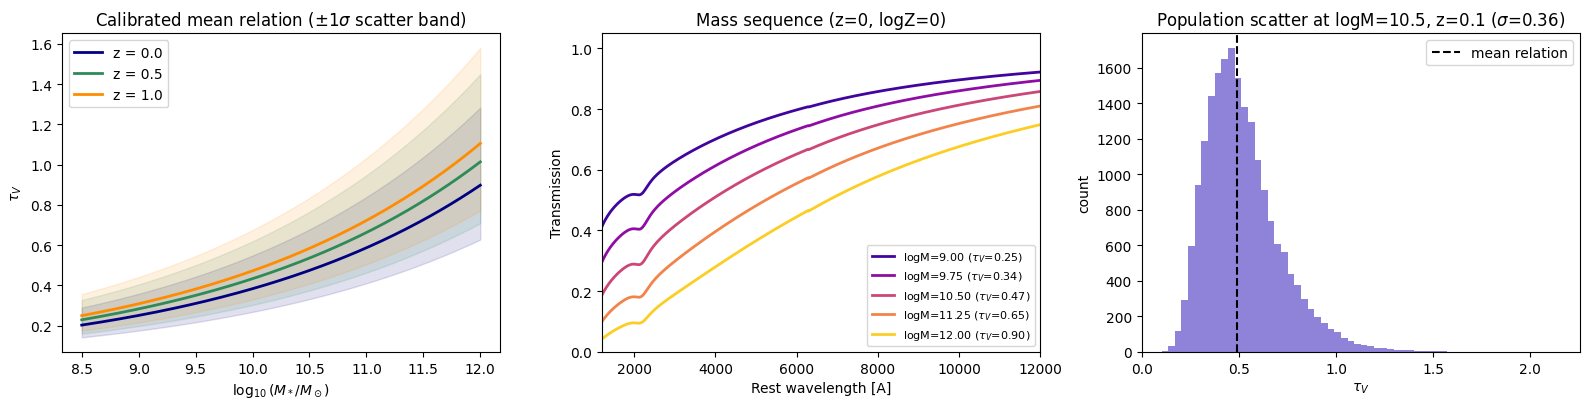

In [6]:
wave = np.linspace(1200, 30000, 2000)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# --- tau_V vs stellar mass at the calibrated relation
ax = axes[0]
logM = np.linspace(8.5, 12.0, 200)
for z_gal, c in [(0.0, 'navy'), (0.5, 'seagreen'), (1.0, 'darkorange')]:
    mean = tau_v_mean(logM, 0.0, z_gal)
    ax.plot(logM, mean, color=c, lw=2, label=f'z = {z_gal}')
    ax.fill_between(logM, mean * np.exp(-CALIBRATED_PARAMS['sigma']),
                    mean * np.exp(CALIBRATED_PARAMS['sigma']),
                    color=c, alpha=0.12)
ax.set_xlabel(r'$\log_{10}(M_*/M_\odot)$'); ax.set_ylabel(r'$\tau_V$')
ax.set_title('Calibrated mean relation ($\pm1\sigma$ scatter band)')
ax.legend()

# --- transmission curves along the mass sequence
ax = axes[1]
colors = cm.plasma(np.linspace(0.1, 0.9, 5))
for logM_val, c in zip([9.0, 9.75, 10.5, 11.25, 12.0], colors):
    tv = float(tau_v_mean(logM_val, 0.0, 0.0))
    trans = np.exp(-(tau_diffuse(wave, tv, CALIBRATED_PARAMS['n'])
                     + tau_birthcloud(wave, CALIBRATED_PARAMS['mu'] * tv)))
    ax.plot(wave, trans, color=c, lw=2,
            label=f'logM={logM_val:.2f} ' + r'($\tau_V$=' + f'{tv:.2f})')
ax.set_xlim(1200, 12000); ax.set_ylim(0, 1.05)
ax.set_xlabel('Rest wavelength [A]'); ax.set_ylabel('Transmission')
ax.set_title('Mass sequence (z=0, logZ=0)'); ax.legend(fontsize=8)

# --- population scatter at fixed mass
ax = axes[2]
rng = np.random.default_rng(42)
draws = draw_tau_v(np.full(20000, 10.5), 0.0, 0.1, rng=rng)
ax.hist(draws, bins=60, color='slateblue', alpha=0.75)
ax.axvline(float(tau_v_mean(10.5, 0.0, 0.1)), color='k', ls='--',
           label='mean relation')
ax.set_xlabel(r'$\tau_V$'); ax.set_ylabel('count')
ax.set_title(r'Population scatter at logM=10.5, z=0.1 '
             f"($\sigma$={CALIBRATED_PARAMS['sigma']:.2f})")
ax.legend()

plt.tight_layout(); plt.show()

## Comparison with DustE on a HACC galaxy

Mirrors the DustE application in `04a` (cells using
`load_hacc_galaxy_data_opencosmo`). Requires the HACC test catalog, so these
cells are marked `#|eval: false` like their 04a counterparts.

In [ ]:
#|eval: false
from watercolor.load_sim_stellar_catalog import load_hacc_galaxy_data_opencosmo, OPEN_COSMO_FILE
from watercolor.calculate_csp import calc_fluxes_for_individual_galaxy
from watercolor.load_sps_library import (LIBRARY_FLUX_FILE, LIBRARY_WAVE_FILE,
                                         LIBRARY_AGE_FILE, LIBRARY_METAL_FILE)
from watercolor.dust_attenuation import spectrum_dusted, hidden_prints

particle_file_path = OPEN_COSMO_FILE or os.path.join(
    os.path.dirname(os.getcwd()), "watercolor", "data",
    "test_hacc_stellar_catalog", "haloparticles.hdf5")

fof_halo_tag, if_satellite, gal_tag, stellar_idx, metal, mass, age, x, y, z, vx, vy, vz = \
    load_hacc_galaxy_data_opencosmo(particle_file_path=particle_file_path)

unique_galaxy_tag = np.unique(gal_tag)[0]
spec_wave_ssp, spec_flux_ssp, spec_csp, flux_proxy, gal_stellar_mass = \
    calc_fluxes_for_individual_galaxy(
        gal_tag, metal, mass, age, unique_galaxy_tag,
        LIBRARY_FLUX_FILE, LIBRARY_WAVE_FILE, LIBRARY_AGE_FILE, LIBRARY_METAL_FILE)

mask_gal = gal_tag == unique_galaxy_tag
mstar_i, metal_i = mass[mask_gal], metal[mask_gal]  # metal already Z/Zsun
logmstar = np.array([np.log10(np.sum(mstar_i))])
logZ_Zsun = np.array([np.log10(np.sum(mstar_i * metal_i) / np.sum(mstar_i))])
galaxy_z = 0.001

print(f'galaxy {unique_galaxy_tag}: logM*={logmstar[0]:.2f}, '
      f'logZ={logZ_Zsun[0]:.2f}')

In [ ]:
#|eval: false
# DustE (original, z=0.001 is an extrapolation for it) vs calibrated model
spec_duste = spectrum_dusted(spec_csp, spec_wave_ssp, logmstar, logZ_Zsun, galaxy_z)

rng = np.random.default_rng(7)
spec_calib = spectrum_dusted_calibrated(spec_csp, spec_wave_ssp,
                                        logmstar, logZ_Zsun, galaxy_z, rng=rng)
tv_here = float(tau_v_mean(logmstar[0], logZ_Zsun[0], galaxy_z))

wmask = (spec_wave_ssp >= 1200) & (spec_wave_ssp <= 12000)
wv = spec_wave_ssp[wmask]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
ax.plot(wv, spec_csp[wmask], 'k-', lw=2, alpha=0.8, label='No dust')
ax.plot(wv, spec_duste[wmask], 'b-', lw=2, label='DustE (extrapolated at z~0)')
ax.plot(wv, spec_calib[wmask], 'r--', lw=2,
        label=f'Calibrated model (mean tau_V={tv_here:.2f})')
ax.set_xlim(3000, 11000)
ax.set_xlabel('Wavelength [A]'); ax.set_ylabel(r'$L_\lambda$ [$L_\odot$/A]')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(wv, spec_duste[wmask] / spec_csp[wmask], 'b-', lw=2, label='DustE')
ax.plot(wv, spec_calib[wmask] / spec_csp[wmask], 'r--', lw=2, label='Calibrated')
ax.axhline(1.0, color='k', lw=0.8, ls=':', alpha=0.5)
ax.set_xlim(3000, 11000); ax.set_ylim(0, 1.1)
ax.set_xlabel('Wavelength [A]'); ax.set_ylabel('Transmission')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## Recalibrating

The calibration harness (survey-agnostic; SDSS / DEEP2 / VIPERS / PRIMUS
tables available, WISE pluggable when a real catalog exists) lives at:

```bash
conda activate env_jax_2024
cd /lcrc/project/cosmo_ai/nramachandra/Projects/SPHEREx/MAH/SEDPhot_v2
python calibration/make_dustless_library.py --n 4000 --nproc 8
python calibration/calibrate_dust.py --surveys SDSS DEEP2 --fit a b sigma n mu
```

This refreshes `outputs/dust_model_calibrated.json`, which the parameter
cell above picks up automatically. Diagnostics land next to the JSON;
the validation triangle plot is `SEDPhot_v2/validation/triangle_plot_v2.png`.

**Reminder on survey color files** (`.../Original_fromJonas/*.npy`): the
`colors` columns are `[u-g, g-i, r-i, i-z, mag_i]` — the "i−r"/"r−z" labels
on the legacy triangle plots are misnomers; using literal i−r/r−z makes dust
anti-correlate with the data and drives any calibration to zero.